### Quantitative Analysis (Technical Indicators)

In [5]:
import pandas as pd
import talib
import seaborn as sns
import matplotlib.pyplot as plt
import os

 1. LOAD AND COMBINE DATA

In [6]:
DATA_PATH = '../data/' 
TICKERS = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']

def load_and_calculate():
    all_stock_data = []

    for ticker in TICKERS:
        file_path = os.path.join(DATA_PATH, f"{ticker}.csv")
        
        if os.path.exists(file_path):
            # Load individual stock file
            df = pd.read_csv(file_path)
            df['Date'] = pd.to_datetime(df['Date'])
            df = df.sort_values('Date')

            # 20-Day Simple Moving Average
            df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
            # Relative Strength Index (Momentum)
            df['RSI'] = talib.RSI(df['Close'], timeperiod=14)
            
            # Daily Returns (Percentage Change)
            df['Daily_Return'] = df['Close'].pct_change()
            
            # Identify the stock
            df['Ticker'] = ticker
            
            all_stock_data.append(df)
            print(f"✅ Processed {ticker}")
        else:
            print(f"⚠️ Warning: File for {ticker} not found at {file_path}")

    combined_df = pd.concat(all_stock_data, ignore_index=True)
    return combined_df

In [7]:
# Execute the workflow
df_final = load_and_calculate()

✅ Processed AAPL
✅ Processed AMZN
✅ Processed GOOG
✅ Processed META
✅ Processed NVDA


In [8]:
# Display the top rows of the combined results
print("\n--- Final Combined Data Preview ---")
print(df_final[['Date', 'Ticker', 'Close', 'SMA_20', 'RSI', 'Daily_Return']].tail(10))


--- Final Combined Data Preview ---
            Date Ticker      Close     SMA_20        RSI  Daily_Return
18009 2023-12-15   NVDA  48.865501  47.732439  58.765888      0.011169
18010 2023-12-18   NVDA  50.051899  47.771586  63.164028      0.024279
18011 2023-12-19   NVDA  49.579140  47.731577  60.399383     -0.009445
18012 2023-12-20   NVDA  48.086884  47.640193  52.576776     -0.030098
18013 2023-12-21   NVDA  48.965446  47.654100  56.175512      0.018270
18014 2023-12-22   NVDA  48.805527  47.706983  55.352119     -0.003266
18015 2023-12-26   NVDA  49.254299  47.759019  57.245971      0.009195
18016 2023-12-27   NVDA  49.392231  47.838989  57.837928      0.002800
18017 2023-12-28   NVDA  49.497185  47.908266  58.310919      0.002125
18018 2023-12-29   NVDA  49.497185  48.046003  58.310919      0.000000


2. Visualization and Analysis

Create a Comparison Chart (RSI & Price)

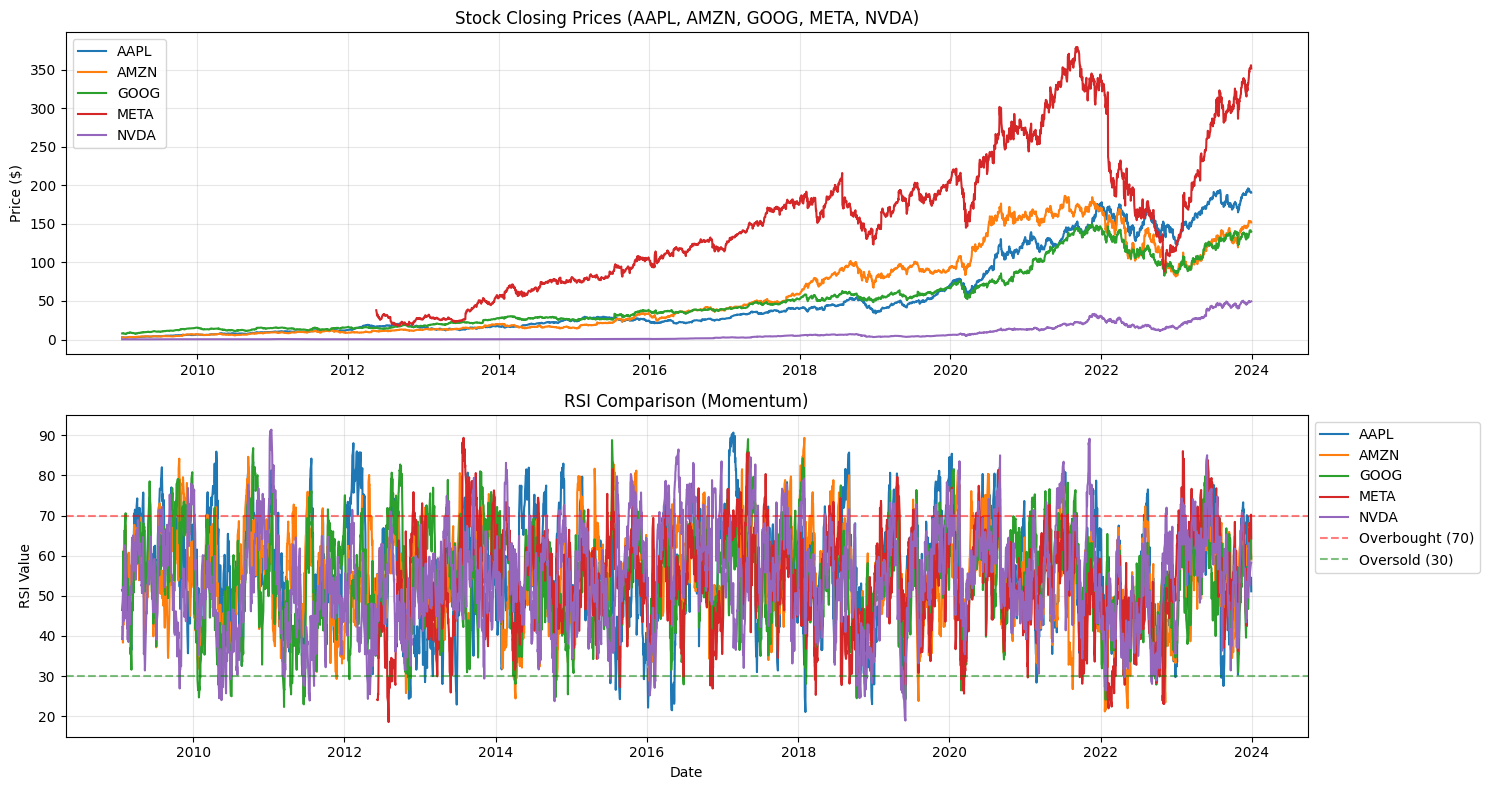

In [9]:
def plot_stock_trends(df):
    plt.figure(figsize=(15, 8))
    
    # Plot 1: Closing Prices
    plt.subplot(2, 1, 1)
    for ticker in df['Ticker'].unique():
        subset = df[df['Ticker'] == ticker]
        plt.plot(subset['Date'], subset['Close'], label=ticker)
    plt.title('Stock Closing Prices (AAPL, AMZN, GOOG, META, NVDA)')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 2: RSI Comparison
    plt.subplot(2, 1, 2)
    for ticker in df['Ticker'].unique():
        subset = df[df['Ticker'] == ticker]
        plt.plot(subset['Date'], subset['RSI'], label=ticker)
    
    # Add RSI threshold lines
    plt.axhline(70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
    plt.axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
    
    plt.title('RSI Comparison (Momentum)')
    plt.ylabel('RSI Value')
    plt.xlabel('Date')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('stock_technical_analysis.png') # Save for your report
    plt.show()

# Run the plot function
plot_stock_trends(df_final)

Calculate Volatility and Moving Average Crossovers

In [16]:
# Calculate 30-day Rolling Volatility
df_final['Volatility'] = df_final.groupby('Ticker')['Daily_Return'].transform(lambda x: x.rolling(window=30).std())


In [14]:
# Identify 'Golden Cross' (Bullish Signal)
# When a 20-day SMA crosses above a 50-day SMA (Optional but professional)
df_final['SMA_50'] = df_final.groupby('Ticker', group_keys=False).apply(lambda x: talib.SMA(x['Close'], timeperiod=50))

print("\n--- Volatility and Trend Analysis Complete ---")
print(df_final[['Date', 'Ticker', 'Volatility', 'SMA_20', 'SMA_50']].tail())



--- Volatility and Trend Analysis Complete ---
            Date Ticker  Volatility     SMA_20     SMA_50
18014 2023-12-22   NVDA    0.018594  47.706983  46.257777
18015 2023-12-26   NVDA    0.017895  47.759019  46.334178
18016 2023-12-27   NVDA    0.017874  47.838989  46.400666
18017 2023-12-28   NVDA    0.017449  47.908266  46.512367
18018 2023-12-29   NVDA    0.017201  48.046003  46.658888
